<div style="background-color: #1A3A5C; padding: 30px; border-radius: 10px; text-align: center;">
  <h1 style="color: white; font-size: 2em; margin-bottom: 8px;">
     Laboratório — Alteração da Taxa de Amostragem
  </h1>
  <h2 style="color: #AED6F1; font-weight: normal; margin-bottom: 6px;">
    Decimação · Interpolação 
  </h2>
  <h3 style="color: #AED6F1; font-weight: normal; margin-bottom: 4px;">
    Disciplina: Processamento Digital de Sinais
  </h3>
  <h3 style="color: #AED6F1; font-weight: normal;">
    Professora: Luciana Ribeiro Veloso — UFCG / DEE
  </h3>
</div>

---

## Sobre este laboratório

Notebook autocontido — todos os experimentos rodam diretamente aqui,
sem dependência de arquivos externos. Os pipelines dos fluxogramas `.grc`
foram transcritos para Python.

| Seção | Conteúdo |
|---|---|
| **1** | Motivação auditiva — `DecimaInterpolaMusica.grc` |
| **2** | Decimação — teoria + `Decimacao.grc` |
| **2b** | Experimento visual com imagem |
| **3** | Simulador de Decimação (slider M) |
| **4** | Interpolação — teoria + `Resampling.grc` |
| **5** | Simulador de Interpolação (slider L) |
| **6** | Experimento com voz ao vivo |
| **7** | Conversão Racional L/M |
| **8** | Roteiro de sala |
| **9** | Questões |

> **Pré-requisito:** Teorema de Nyquist, espectro de sinais amostrados, filtros passa-baixa.


---

##  Configuração — execute esta célula antes de qualquer experimento

Esta célula importa todas as bibliotecas utilizadas no laboratório e
configura o estilo visual padrão dos gráficos. **Execute-a uma única vez ao abrir o notebook.**


In [3]:
# ── Bibliotecas científicas ───────────────────────────────────────
import numpy as np
from scipy.signal import resample_poly, spectrogram, butter, filtfilt
from scipy.ndimage import gaussian_filter
from scipy.io import wavfile
from skimage import data
from skimage.transform import resize as sk_resize

# ── Visualização ──────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

# ── Áudio e interatividade ────────────────────────────────────────
from IPython.display import Audio, display, HTML
import sounddevice as sd
import IPython.display as ipd
import ipywidgets as widgets

# ── Estilo visual padrão dos gráficos ─────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f8f9fa',
    'axes.grid'        : True,
    'grid.color'       : '#dee2e6',
    'grid.linewidth'   : 0.6,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 11,
    'axes.titlesize'   : 12,
    'axes.titleweight' : 'bold',
})

# ── Paleta de cores padrão do laboratório ─────────────────────────
C_ORIG  = '#1A5FA8'   # azul   — sinal / imagem original
C_DSEM  = '#C0392B'   # verm.  — sem filtro (artefatos)
C_DCOM  = '#117A65'   # verde  — com filtro (correto)
C_INTERP= '#8E44AD'   # roxo   — sinal interpolado
C_ZEROS = '#E67E22'   # laran. — zeros inseridos
C_NYQ   = '#E67E22'   # laran. — linha de Nyquist
C_CINZA = '#5D6D7E'   # cinza  — referência / baixa resolução

print('Configuração concluída — pode executar as seções a seguir.')


Configuração concluída — pode executar as seções a seguir.


---

## <span style="color: #1A5FA8;">1. Motivação Auditiva — Música com Resampling</span>

O Código a seguir carrega `handel.wav` e aplica um
`rational_resampler` com fatores `interp` e `decim` configuráveis.
A célula abaixo é a transcrição direta desse pipeline:

```
handel.wav (repeat)  →  rational_resampler(interp, decim)  →  Audio Sink
```

>Por que começar pelo ouvido?</strong><br>
Antes de qualquer equação, o cérebro precisa de uma <em>âncora perceptiva</em>.
Ouça a música degradar com cada fator — quando a fórmula $x_d(n) = x(nM)$
aparecer, ela já terá significado concreto.
</div>

| `interp` | `decim` | $F_s$ resultante | O que esperar |
|:---:|:---:|:---:|---|
| 1 | 1 | 8.192 Hz | Referência — qualidade original |
| 1 | 2 | 4.096 Hz | Leve perda de brilho |
| 1 | 4 | 2.048 Hz | Agudos somem, voz abafada |
| 1 | 8 | 1.024 Hz | Quase irreconhecível |
| 2 | 1 | 16.384 Hz | Deve soar igual ao original |



### Etapa 1 — Parâmetros e obter o sinal de audio

In [5]:
# ── Parâmetros (correspondem às variáveis do DecimaInterpolaMusica.grc) ──
SAMP_RATE = 8192   # Hz — taxa de amostragem do arquivo handel.wav
duracao   = 4.0    # s

# Fatores a demonstrar (equivalem a alterar interp/decim no GRC)
experimentos = [
    (1, 1),   # sem alteração — referência
    (1, 2),   # decimação por 2
    (1, 4),   # decimação por 4
    (1, 8),   # decimação por 8
    (2, 1),   # interpolação por 2
]

# 1. Caminho do arquivo
caminho = "/Users/lucianaveloso/Library/CloudStorage/GoogleDrive-luciana.veloso@dee.ufcg.edu.br/Meu Drive/UFCG/Disciplinas/PDS/2026/Labs/handel.wav"

# 2. Abrir o arquivo de áudio corretamente usando scipy
try:
    SAMP_RATE, dados = wavfile.read(caminho)
    
    # Se o áudio for estéreo (2 colunas), converte para mono para facilitar o PDS
    if len(dados.shape) > 1:
        dados = dados[:, 0]
        
    # Normalização: Converter para float entre -1.0 e 1.0
    sinal_orig = dados.astype(float) / np.max(np.abs(dados))
    
    frames = len(sinal_orig)
    print(f"Número de amostras (frames): {frames}")
    print(f"Taxa de amostragem original: {SAMP_RATE} Hz")
except FileNotFoundError:
    print("Erro: Arquivo não encontrado. Verifique o caminho.")
    # Fallback: criar um sinal sintético caso o arquivo não exista para não travar o loop
    SAMP_RATE = 8000
    t = np.linspace(0, 2, 16000)
    sinal_orig = np.sin(2 * np.pi * 440 * t)


print(f'Sinal gerado: {len(sinal_orig):,} amostras  |  Fs = {SAMP_RATE} Hz  |  {duracao:.1f} s')



Erro: Arquivo não encontrado. Verifique o caminho.
Sinal gerado: 16,000 amostras  |  Fs = 8000 Hz  |  4.0 s


### Etapa 2 — Aplicar resampling e reproduzir

Cada configuração de `interp`/`decim` equivale a um ajuste no `rational_resampler` do GNU Radio.

In [6]:
print('Pipeline: sinal  →  rational_resampler(interp, decim)  →  Audio Sink')
print(f'Fs original = {SAMP_RATE} Hz')
print('=' * 65)

for interp, decim in experimentos:
    sinal_res = resample_poly(sinal_orig, interp, decim) if (interp, decim) != (1,1)                 else sinal_orig.copy()
    fs_nova = int(SAMP_RATE * interp / decim)
    label   = 'referência' if (interp, decim) == (1,1) else               f'interpolação ×{interp}' if decim == 1 else f'decimação ×{decim}'

    display(HTML(f'<b>interp={interp}, decim={decim} &nbsp;|&nbsp; '
                 f'Fs = {fs_nova} Hz &nbsp;|&nbsp; {label}</b>'))
    display(Audio(sinal_res, rate=fs_nova))
    print(f'  {len(sinal_res):,} amostras  |  Nyquist = {fs_nova//2} Hz')

print('=' * 65)
print('Observe: a interpolação por 2 deve soar idêntica ao original.')


Pipeline: sinal  →  rational_resampler(interp, decim)  →  Audio Sink
Fs original = 8000 Hz


  16,000 amostras  |  Nyquist = 4000 Hz


  8,000 amostras  |  Nyquist = 2000 Hz


  4,000 amostras  |  Nyquist = 1000 Hz


  2,000 amostras  |  Nyquist = 500 Hz


  32,000 amostras  |  Nyquist = 8000 Hz
Observe: a interpolação por 2 deve soar idêntica ao original.


### 💡 O que observar

>Escuta comparativa</strong><br>
Os harmônicos mais agudos desaparecem progressivamente com a decimação.
A interpolação por 2 deve soar <em>idêntica</em> ao original — o filtro interno
do <code>rational_resampler</code> remove as imagens automaticamente.

>Para registrar</strong><br>
Em qual fator de decimação os harmônicos somem completamente?
Calcule: $F_{Nyquist}^{dec} = F_s/(2M)$ e compare com o harmônico mais agudo (3.520 Hz).


---

## <span style="color: #1A5FA8;">2. Decimação — Teoria e Pipeline</span>

### Definição

A **decimação por $M$** mantém 1 amostra a cada $M$, descartando as demais:

$$\boxed{x_d(n) = x(nM) = x_c(nMT), \qquad T_d = MT}$$

**Exemplo M = 2:** 

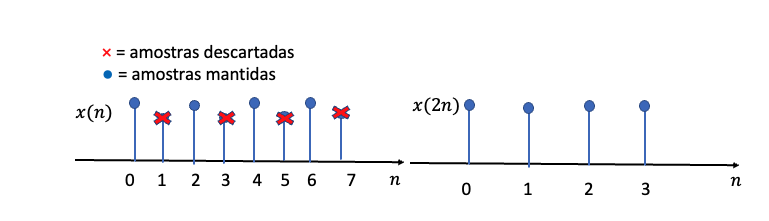

O período de amostragem dobra: $T_d = 2T$, a taxa cai para $F_s/2$.

### Efeito espectral

A decimação **expande** o espectro por $M$ e cria $M-1$ réplicas:

$$\boxed{X_d(e^{j\omega}) = \frac{1}{M} \sum_{k=0}^{M-1} X\!\left(e^{j(\omega - 2\pi k)/M}\right)}$$


**Interpretação:** o espectro de $x(n)$ (que ocupava $[-\pi, \pi]$)
é esticado por $M$ e dobrado de volta na periodicidade $2\pi$ — gerando $M$ cópias.

### Caso 1 — Sem aliasing: $\omega_N < \pi/M$

Quando a banda do sinal é menor que $\pi/M$, as $M$ cópias ficam separadas:

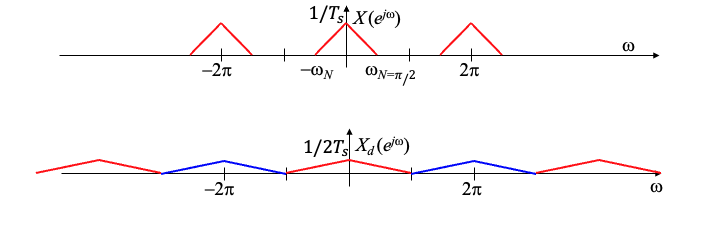

O sinal pode ser recuperado por um filtro passa-baixa com corte em $\pi/M$.

### Caso 2 — Com aliasing: $\omega_N > \pi/M$

As cópias se sobrepõem — **distorção irreversível**:

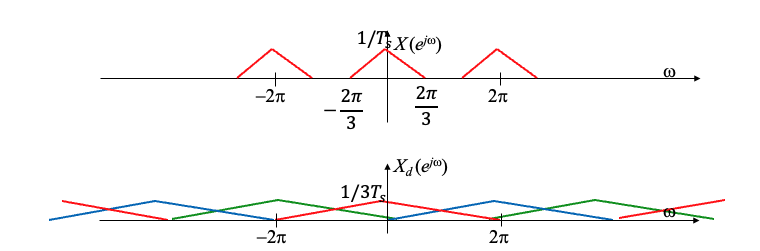

<div style="background-color: #FDEDEC; border-left: 4px solid #A32D2D; padding: 12px; border-radius: 4px; margin: 12px 0;">
<strong style="color: #A32D2D;">Aliasing é irreversível:</strong> uma vez que as réplicas se sobrepõem,
nenhum processamento posterior recupera o sinal original.
O filtro anti-aliasing deve ser aplicado <em>antes</em> do compressor.
</div>

### Antialiasing — filtro antes de decimar

Aplica-se um filtro passa-baixa $H_d(e^{j\omega})$ com corte em $\pi/M$ **antes** do compressor.


### Pipeline completo do decimador

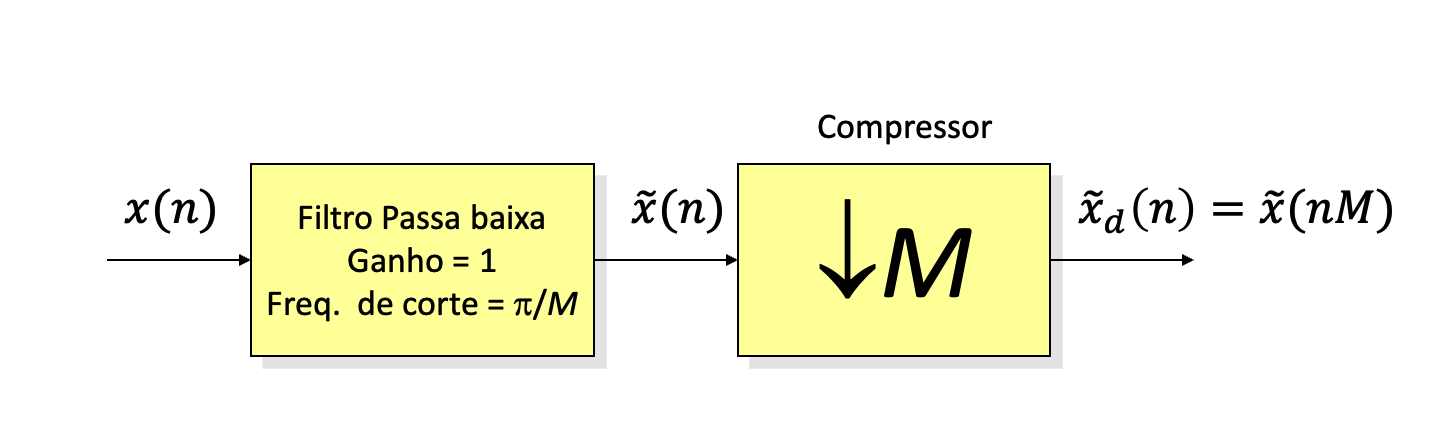

### Experimento 02 -

O código a seguir compara três decimações simultâneas de uma cosseno de 1.000 Hz:

```
cos(1000 Hz) @ Fs = 48.000 Hz
    ├── Resampler (decim=1) → "Espectro original"    (azul)
    ├── Resampler (decim=2) → "Espectro Decimado 1"  (vermelho)
    └── Resampler (decim=4) → "Espectro Decimado 2"  (verde)
              
```


### Etapa 1 — Parâmetros do experimento

In [7]:
# ── Parâmetros (correspondem ao Decimacao.grc) ────────────────────
samp_rate = 48000   # Hz — taxa de amostragem original
freq_cos  = 1000    # Hz — frequência da cosseno (altere para ver aliasing)
amp       = 1.0
T_dur     = 0.05    # s  — janela de visualização

fatores   = [1, 2, 10]
labels_t  = ['x(n)', 'x_2(n)', 'x_3(n)']
labels_f  = ['Espectro original', 'Espectro Decimado 1', 'Espectro Decimado 2']
cores_dec = [C_ORIG, C_DSEM, C_DCOM]

# ── Sinal fonte: cosseno (analog_sig_source_x) ────────────────────
N_orig = int(samp_rate * T_dur)
t_orig = np.linspace(0, T_dur, N_orig, endpoint=False)
x_orig = amp * np.cos(2 * np.pi * freq_cos * t_orig)

print(f'cos({freq_cos} Hz) @ Fs = {samp_rate} Hz  |  {N_orig} amostras')
print()
print(f'{"M":>4} | {"Fs_y (Hz)":>10} | {"Nyquist (Hz)":>13} | Status')
print('-' * 48)
for M in fatores:
    fs_y = samp_rate / M
    nyq  = fs_y / 2
    ok   = freq_cos < nyq
    print(f'{M:>4} | {fs_y:>10.1f} | {nyq:>13.1f} | {"✅ sem aliasing" if ok else "⚠️  COM ALIASING"}')


cos(1000 Hz) @ Fs = 48000 Hz  |  2400 amostras

   M |  Fs_y (Hz) |  Nyquist (Hz) | Status
------------------------------------------------
   1 |    48000.0 |       24000.0 | ✅ sem aliasing
   2 |    24000.0 |       12000.0 | ✅ sem aliasing
  10 |     4800.0 |        2400.0 | ✅ sem aliasing


### Etapa 2 — Processar cada caminho (rational_resampler)

In [8]:
# Decimar por cada fator (resample_poly aplica filtro AA automaticamente)
sinais_dec = []
for M in fatores:
    s = x_orig.copy() if M == 1 else resample_poly(x_orig, 1, M)
    sinais_dec.append(s)
    print(f'M = {M:2d}: {len(s):5d} amostras  |  Fs = {samp_rate/M:.0f} Hz')


M =  1:  2400 amostras  |  Fs = 48000 Hz
M =  2:  1200 amostras  |  Fs = 24000 Hz
M = 10:   240 amostras  |  Fs = 4800 Hz


### Etapa 3 — Visualizar formas de onda 

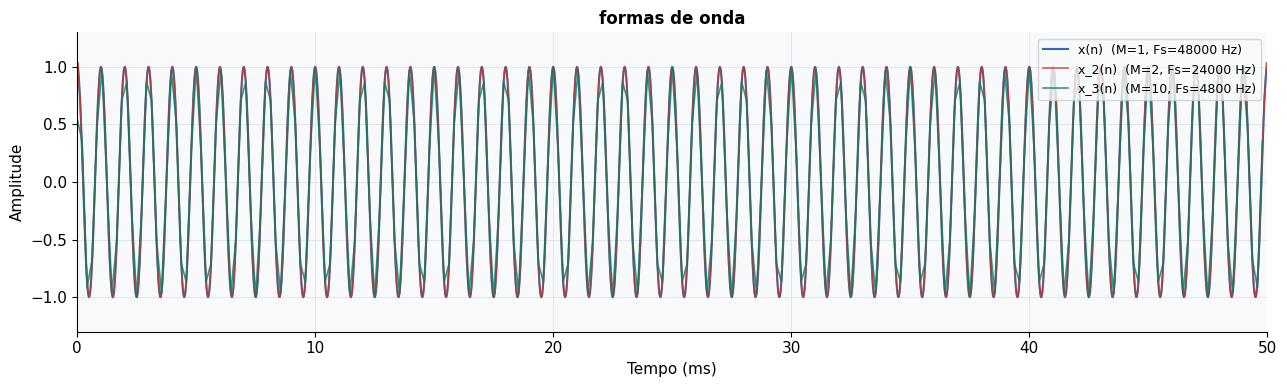

In [9]:
fig, ax_t = plt.subplots(figsize=(13, 4))
N_fft = 4096

for M, sinal, lt, cor in zip(fatores, sinais_dec, labels_t, cores_dec):
    fs_y = samp_rate / M
    t_ms = np.arange(len(sinal)) / fs_y * 1000
    ax_t.plot(t_ms, sinal, color=cor, lw=1.5 if M == 1 else 1.2,
              label=f'{lt}  (M={M}, Fs={fs_y:.0f} Hz)',
              alpha=0.9 if M == 1 else 0.8)

ax_t.set_title('formas de onda', fontweight='bold')
ax_t.set_xlabel('Tempo (ms)'); ax_t.set_ylabel('Amplitude')
ax_t.set_xlim([0, T_dur * 1000]); ax_t.set_ylim([-1.3, 1.3])
ax_t.legend(fontsize=9); plt.tight_layout(); plt.show()


### Etapa 4 — Visualizar espectros 

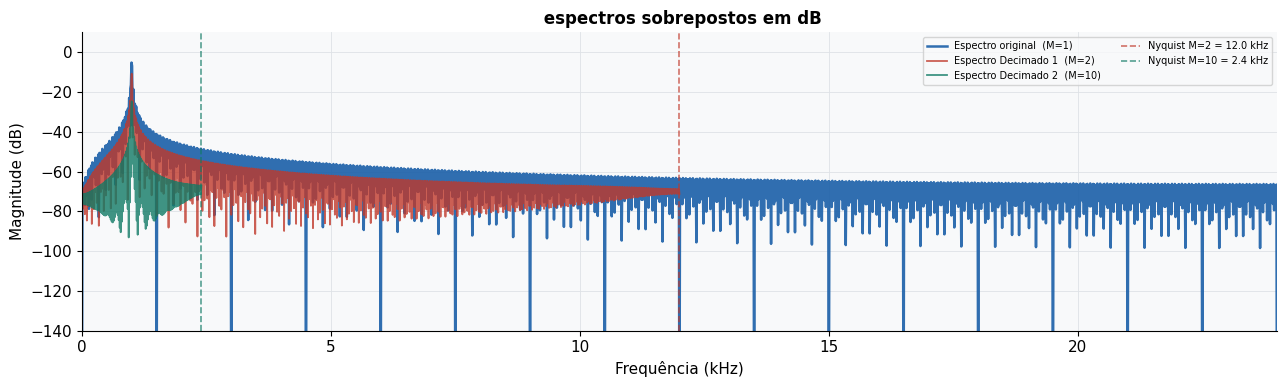


💡 Dica: altere freq_cos = 13000 na Etapa 1 e reexecute para ver aliasing.


In [10]:
fig, ax_f = plt.subplots(figsize=(13, 4))
N_fft = 4096

for M, sinal, lf, cor in zip(fatores, sinais_dec, labels_f, cores_dec):
    fs_y = samp_rate / M
    X    = np.abs(np.fft.rfft(sinal, n=N_fft)) / N_fft * 2
    f_hz = np.fft.rfftfreq(N_fft, d=1.0 / fs_y)
    ax_f.plot(f_hz / 1000, 20 * np.log10(X + 1e-10), color=cor,
              lw=1.8 if M == 1 else 1.3, alpha=0.9 if M == 1 else 0.8,
              label=f'{lf}  (M={M})')

# Linhas de Nyquist para cada decimador
for M, cor in zip(fatores[1:], cores_dec[1:]):
    nyq = samp_rate / M / 2 / 1000
    ax_f.axvline(nyq, color=cor, lw=1.2, ls='--', alpha=0.7,
                 label=f'Nyquist M={M} = {nyq:.1f} kHz')

ax_f.set_title(' espectros sobrepostos em dB', fontweight='bold')
ax_f.set_xlabel('Frequência (kHz)'); ax_f.set_ylabel('Magnitude (dB)')
ax_f.set_xlim([0, samp_rate / 2 / 1000]); ax_f.set_ylim([-140, 10])
ax_f.legend(fontsize=7, ncol=2); plt.tight_layout(); plt.show()

print()
print('💡 Dica: altere freq_cos = 13000 na Etapa 1 e reexecute para ver aliasing.')


### 💡 O que observar

Aqui está o texto completo da célula reescrita:

---

### 💡 O que observar

<div style="background-color: #EAFAF1; border-left: 4px solid #117A65; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #117A65;">No espectro — qtgui_freq_sink</strong><br>
O sinal de 1.000 Hz está bem abaixo dos Nyquists de todos os decimadores
($F_{Nyquist}^{M=2} = 12$ kHz e $F_{Nyquist}^{M=4} = 6$ kHz) — portanto
não há aliasing visível para nenhum dos três caminhos.
Observe as linhas tracejadas de Nyquist para M=2 e M=4: o pico em 1 kHz
permanece na mesma posição nos três espectros.<br><br>
<strong>Para ver aliasing:</strong> altere <code>freq_cos = 13000</code>
e reexecute. O pico aparecerá em posições diferentes para cada M.
</div>

<div style="background-color: #EAF2FB; border-left: 4px solid #1A5FA8; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #1A5FA8;">No domínio do tempo — qtgui_time_sink</strong><br>
Para os três fatores (M=1, 2, 4), a forma senoidal se mantém reconhecível —
evidência de que sem aliasing a decimação preserva a frequência do sinal,
apenas reduzindo o número de amostras disponíveis para representá-la.

Ao explorar valores maiores de M no Simulador da Seção 3, dois efeitos
progressivos se tornam visíveis:

**1. Subamostragem visual** — conforme M cresce, $F_s/M$ se aproxima de $F_0$.
Com menos amostras por ciclo, o gráfico (que conecta pontos com linhas retas)
perde a capacidade de representar a curvatura da senoide. A forma de onda
parece "serrilhada" ou irregular — mas atenção: isso é um artefato de
visualização, não distorção do sinal. A informação da frequência permanece
intacta nas amostras.

**2. Atenuação pelo filtro anti-aliasing** — quanto maior M, mais baixa é a
frequência de corte $\omega_c = \pi/M$ do filtro passa-baixa. Quando $F_0$
se aproxima dessa fronteira, o sinal entra na banda de transição do filtro
e começa a ser atenuado. Isso explica por que a amplitude máxima do sinal
decimado pode ser menor que a do original para M elevado.
</div>

>Distinção importante</strong><br>
Os dois efeitos acima <em>não são aliasing</em> — são consequências do número
reduzido de amostras e da banda limitada pelo filtro. O aliasing verdadeiro
só ocorre quando $F_0 > F_s/(2M)$, situação em que um pico falso aparece
no espectro em posição diferente de $F_0$. Verifique essa distinção no
Simulador da Seção 3 comparando M=4 (caso limite) com M=5 (aliasing real).

---

## <span style="color: #1A5FA8;">2b. Experimento Visual — Decimação e Interpolação em Imagem</span>

<div style="background-color: #EAF2FB; border-left: 4px solid #1A5FA8; padding: 14px; border-radius: 4px; margin: 12px 0;">
<strong style="color: #1A5FA8;">Por que usar uma imagem?</strong><br>
Uma imagem digital é um sinal discreto bidimensional $x(m, n)$ onde $m$ e $n$
são índices de linha e coluna. Os <strong>mesmos princípios</strong> se aplicam:

- **Decimação por M:** manter 1 pixel a cada M → imagem menor. Sem filtro, surgem artefatos (aliasing espacial = serrilhado, moiré).
- **Interpolação por L:** inserir L-1 novos pixels entre cada par → imagem maior. Sem filtro, os zeros aparecem como <em>blocos pretos</em>.
</div>

### Conexão com a teoria

| Sinais 1D | Imagens 2D |
|---|---|
| Amostras $x(n)$ | Pixels $x(m, n)$ |
| Taxa $F_s$ (Hz) | Resolução (pixels/polegada) |
| $x_d(n) = x(nM)$ | $x_d(m,n) = x(mM, nM)$ |
| Aliasing espectral | Aliasing espacial (serrilhado) |
| Zeros → imagens espectrais | Zeros → blocos pretos |
| Filtro LPF elimina imagens | Suavização elimina blocos |

A figura gerada tem **4 linhas**:

| Linha | O que mostra |
|---|---|
| 1 — Decimação **sem** filtro  | Aliasing visual (artefatos na grama e bordas) |
| 2 — Decimação **com** filtro  | Sem aliasing, imagem suavizada |
| 3 — Interpolação **sem** filtro  | Zeros = blocos pretos (visível no zoom) |
| 4 — Interpolação **com** filtro  | Interpolação suavizada, sem artefatos |


### Etapa 1 — Carregar imagem e definir funções

In [11]:
# ── Imagem original (512×512, escala de cinza — skimage cameraman) ─
img_orig = data.camera().astype(float)
H, W = img_orig.shape
print(f'Imagem carregada: {W}×{H} pixels')

# ── Funções de decimação ──────────────────────────────────────────
def decimar_sem_filtro(img, M):
    '''x_d(m,n) = x(mM, nM) — mantém 1 pixel a cada M, sem filtro AA.'''
    return img[::M, ::M]

def decimar_com_filtro(img, M):
    '''Filtro Gaussiano (AA) antes de decimar — equivale ao LPF digital.'''
    sigma = M / (2 * np.pi)
    return gaussian_filter(img, sigma=sigma)[::M, ::M]

# ── Funções de interpolação ───────────────────────────────────────
def interpolar_zeros(img, L):
    '''Upsampler ↑L: insere L-1 zeros entre cada pixel — xe(m,n).'''
    H, W = img.shape
    out = np.zeros((H * L, W * L))
    out[::L, ::L] = img
    return out

def interpolar_bilinear(img, L):
    '''Upsampler + filtro bilinear — equivale ao LPF com ganho L.'''
    H, W = img.shape
    return sk_resize(img, (H * L, W * L), order=1,
                     anti_aliasing=False, preserve_range=True)

# ── Imagem de baixa resolução (ponto de partida para interpolação) ─
fatores_dec = [1, 2, 4, 8]
img_baixa   = decimar_com_filtro(img_orig, 4)   # 128×128
Hb, Wb      = img_baixa.shape
print(f'Imagem baixa resolução: {Wb}×{Hb} pixels (ponto de partida para interpolação)')


Imagem carregada: 512×512 pixels
Imagem baixa resolução: 128×128 pixels (ponto de partida para interpolação)


### Etapa 2 — Decimação: sem vs. com filtro anti-aliasing

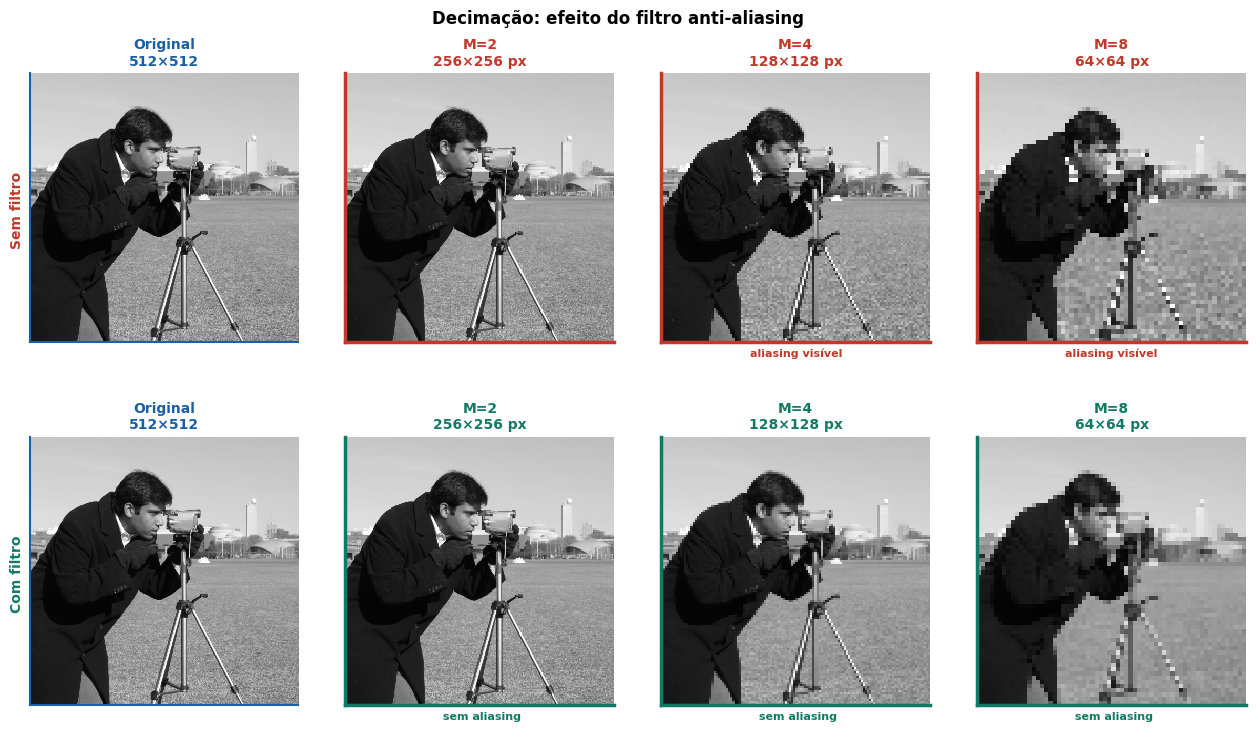

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), facecolor='white')
plt.subplots_adjust(hspace=0.35, wspace=0.08, top=0.90)

def estilizar(ax, cor, lw=2.5):
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_color(cor); s.set_linewidth(lw)

# Linha 0: sem filtro
for col, M in enumerate(fatores_dec):
    ax = axes[0, col]
    img_d = decimar_sem_filtro(img_orig, M)
    h, w  = img_d.shape
    ax.imshow(img_d, cmap='gray', vmin=0, vmax=255,
              extent=[0,W,H,0], interpolation='nearest')
    cor = C_ORIG if M == 1 else C_DSEM
    ax.set_title(f'Original\n{W}×{H}' if M==1 else f'M={M}\n{w}×{h} px',
                 fontsize=10, fontweight='bold', color=cor)
    estilizar(ax, cor, lw=1.5 if M==1 else 2.5)
    if M in [4, 8]:
        ax.set_xlabel('aliasing visível', fontsize=8, color=C_DSEM, fontweight='bold')

# Linha 1: com filtro
for col, M in enumerate(fatores_dec):
    ax = axes[1, col]
    img_d = decimar_com_filtro(img_orig, M)
    h, w  = img_d.shape
    ax.imshow(img_d, cmap='gray', vmin=0, vmax=255,
              extent=[0,W,H,0], interpolation='nearest')
    cor = C_ORIG if M == 1 else C_DCOM
    ax.set_title(f'Original\n{W}×{H}' if M==1 else f'M={M}\n{w}×{h} px',
                 fontsize=10, fontweight='bold', color=cor)
    estilizar(ax, cor, lw=1.5 if M==1 else 2.5)
    if M > 1:
        ax.set_xlabel(' sem aliasing', fontsize=8, color=C_DCOM, fontweight='bold')

axes[0,0].set_ylabel('Sem filtro ', fontsize=10, color=C_DSEM, fontweight='bold')
axes[1,0].set_ylabel('Com filtro ', fontsize=10, color=C_DCOM, fontweight='bold')
fig.suptitle('Decimação: efeito do filtro anti-aliasing', fontsize=12, fontweight='bold')
plt.show()


### Etapa 3 — Interpolação: sem vs. com filtro

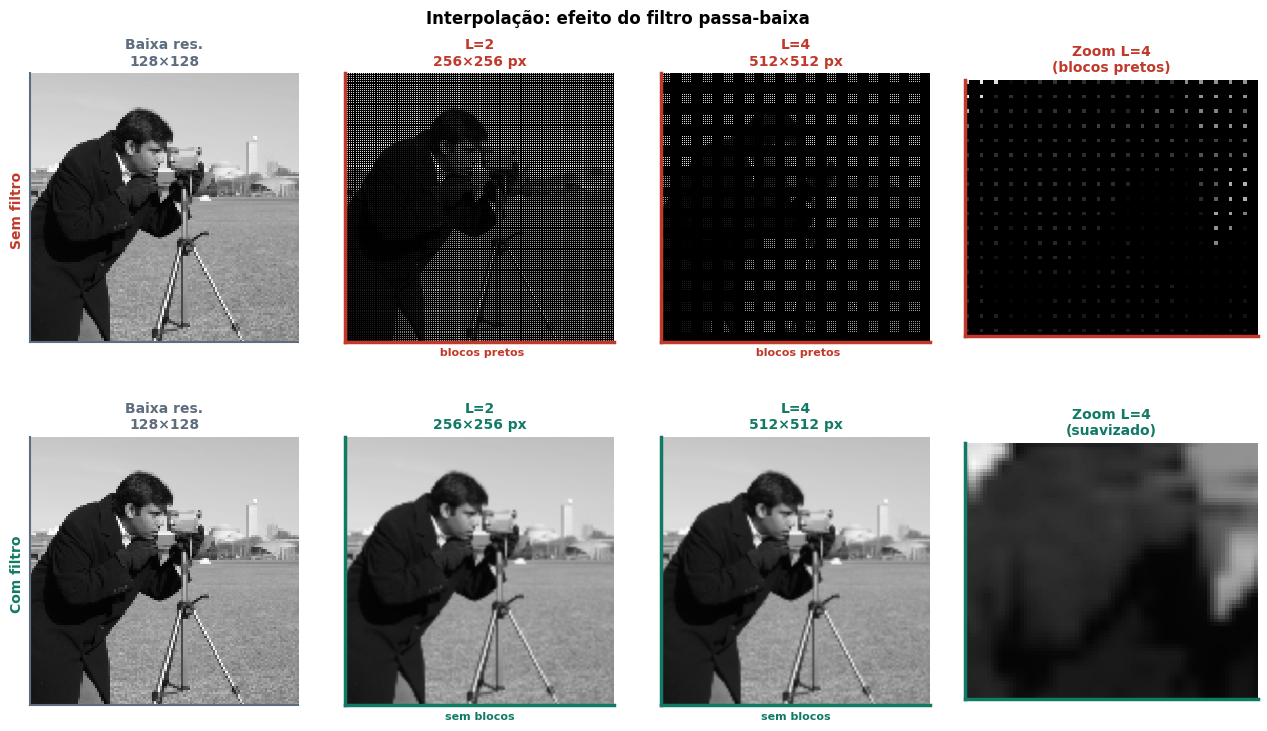

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), facecolor='white')
plt.subplots_adjust(hspace=0.35, wspace=0.08, top=0.90)

# Linha 0: zeros inseridos (sem filtro)
for col, (img_show, titulo, cor, xlabel) in enumerate([
    (img_baixa, f'Baixa res.\n{Wb}×{Hb}', C_CINZA, ''),
    (np.clip(interpolar_zeros(img_baixa,2),0,255), f'L=2\n{Wb*2}×{Hb*2} px', C_DSEM, ' blocos pretos'),
    (np.clip(interpolar_zeros(img_baixa,4),0,255), f'L=4\n{Wb*4}×{Hb*4} px', C_DSEM, ' blocos pretos'),
    (np.clip(interpolar_zeros(img_baixa,4),0,255)[200:270,180:260], 'Zoom L=4\n(blocos pretos)', C_DSEM, ''),
]):
    ax = axes[0, col]
    ax.imshow(img_show, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
    ax.set_title(titulo, fontsize=10, fontweight='bold', color=cor)
    estilizar(ax, cor, lw=1.5 if col==0 else 2.5)
    if xlabel: ax.set_xlabel(xlabel, fontsize=8, color=C_DSEM, fontweight='bold')

# Linha 1: interpolação suavizada (com filtro)
for col, (img_show, titulo, cor, xlabel) in enumerate([
    (img_baixa, f'Baixa res.\n{Wb}×{Hb}', C_CINZA, ''),
    (np.clip(interpolar_bilinear(img_baixa,2),0,255), f'L=2\n{Wb*2}×{Hb*2} px', C_DCOM, 'sem blocos'),
    (np.clip(interpolar_bilinear(img_baixa,4),0,255), f'L=4\n{Wb*4}×{Hb*4} px', C_DCOM, 'sem blocos'),
    (np.clip(interpolar_bilinear(img_baixa,4),0,255)[200:270,180:260], 'Zoom L=4\n(suavizado)', C_DCOM, ''),
]):
    ax = axes[1, col]
    ax.imshow(img_show, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
    ax.set_title(titulo, fontsize=10, fontweight='bold', color=cor)
    estilizar(ax, cor, lw=1.5 if col==0 else 2.5)
    if xlabel: ax.set_xlabel(xlabel, fontsize=8, color=C_DCOM, fontweight='bold')

axes[0,0].set_ylabel('Sem filtro ', fontsize=10, color=C_DSEM, fontweight='bold')
axes[1,0].set_ylabel('Com filtro ', fontsize=10, color=C_DCOM, fontweight='bold')
fig.suptitle('Interpolação: efeito do filtro passa-baixa', fontsize=12, fontweight='bold')
plt.show()


### Etapa 4 — Resumo quantitativo

In [14]:
print(f'{"Fator M":>8} | {"Resolução":>11} | {"Pixels":>10} | {"Redução":>8}')
print('-' * 48)
for M in fatores_dec:
    h=H//M; w=W//M
    print(f'{M:>8} | {w:>5}×{h:<5} | {w*h:>10,} | {100*(1-(w*h)/(H*W)):>7.1f}%')
print()
print(f'{"Fator L":>8} | {"Resolução":>11} | {"Pixels":>10} | {"Aumento":>8}')
print('-' * 48)
for L in [1, 2, 4]:
    h=Hb*L; w=Wb*L
    print(f'{L:>8} | {w:>5}×{h:<5} | {w*h:>10,} | {(w*h)/(Hb*Wb):>7.1f}×')


 Fator M |   Resolução |     Pixels |  Redução
------------------------------------------------
       1 |   512×512   |    262,144 |     0.0%
       2 |   256×256   |     65,536 |    75.0%
       4 |   128×128   |     16,384 |    93.8%
       8 |    64×64    |      4,096 |    98.4%

 Fator L |   Resolução |     Pixels |  Aumento
------------------------------------------------
       1 |   128×128   |     16,384 |     1.0×
       2 |   256×256   |     65,536 |     4.0×
       4 |   512×512   |    262,144 |    16.0×


### 💡 O que observar na figura

<div style="background-color: #FDEDEC; border-left: 4px solid #A32D2D; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #A32D2D;">Linha 1 — Decimação SEM filtro (borda vermelha)</strong><br>
Para M=4 e M=8, surgem artefatos visíveis na grama e nas bordas do tripé.
Isso é o <strong>aliasing espacial</strong>, altas frequências espaciais "dobraram"
para frequências baixas, criando padrões falsos que não existem no original.
</div>

<div style="background-color: #EAFAF1; border-left: 4px solid #117A65; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #117A65;">Linha 2 — Decimação COM filtro (borda verde)</strong><br>
O filtro Gaussiano elimina as altas frequências antes de decimar. A imagem
fica mais suave (perde detalhes finos), mas sem artefatos. Esse é o
compromisso do filtro anti-aliasing: <strong>sacrificamos detalhes para evitar distorções</strong>.
</div>

<div style="background-color: #FDEDEC; border-left: 4px solid #A32D2D; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #A32D2D;">Linha 3 — Interpolação SEM filtro / zeros (borda vermelha)</strong><br>
Os $L-1$ zeros inseridos aparecem como blocos pretos, o equivalente visual das
imagens espectrais do upsampler. O zoom da coluna 4 torna isso inequívoco.
</div>

<div style="background-color: #EAFAF1; border-left: 4px solid #117A65; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #117A65;">Linha 4 — Interpolação COM filtro (borda verde)</strong><br>
A interpolação bilinear (equivalente ao LPF com ganho $L$) preenche os zeros
com valores calculados, imagem ampliada sem blocos pretos.
</div>

**Pergunta:** compare a decimada M=4 com filtro (linha 2) e a interpolada L=4
sem filtro (linha 3). Ambas têm 512×512 pixels mas origens opostas.
Por que a qualidade visual é tão diferente?


---

## <span style="color: #1A5FA8;">4. Interpolação — Teoria e Pipeline</span>

### Definição — dois estágios

**Estágio 1 — Expansão $\uparrow L$: inserção de zeros**

$$x_e(n) = \begin{cases} x(n/L) & n = 0, \pm L, \pm 2L, \ldots \\ 0 & \text{caso contrário} \end{cases}$$

**Exemplo L = 4:** 3 zeros inseridos entre cada par de amostras.

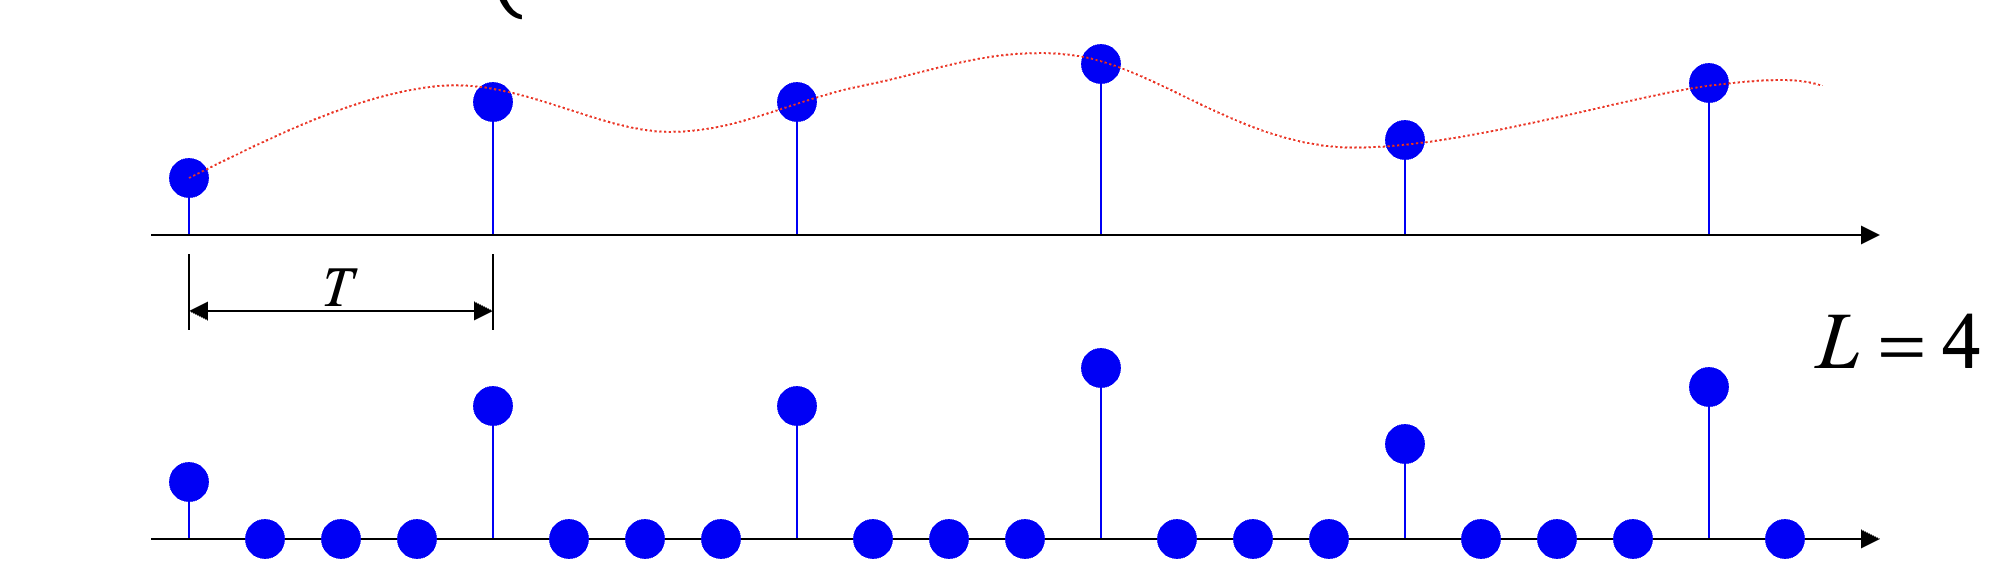

No domínio da frequência, inserir zeros **comprime** o espectro por $L$
e cria $L-1$ **imagens** (cópias):

$$X_e(e^{j\omega}) = X(e^{jL\omega})$$

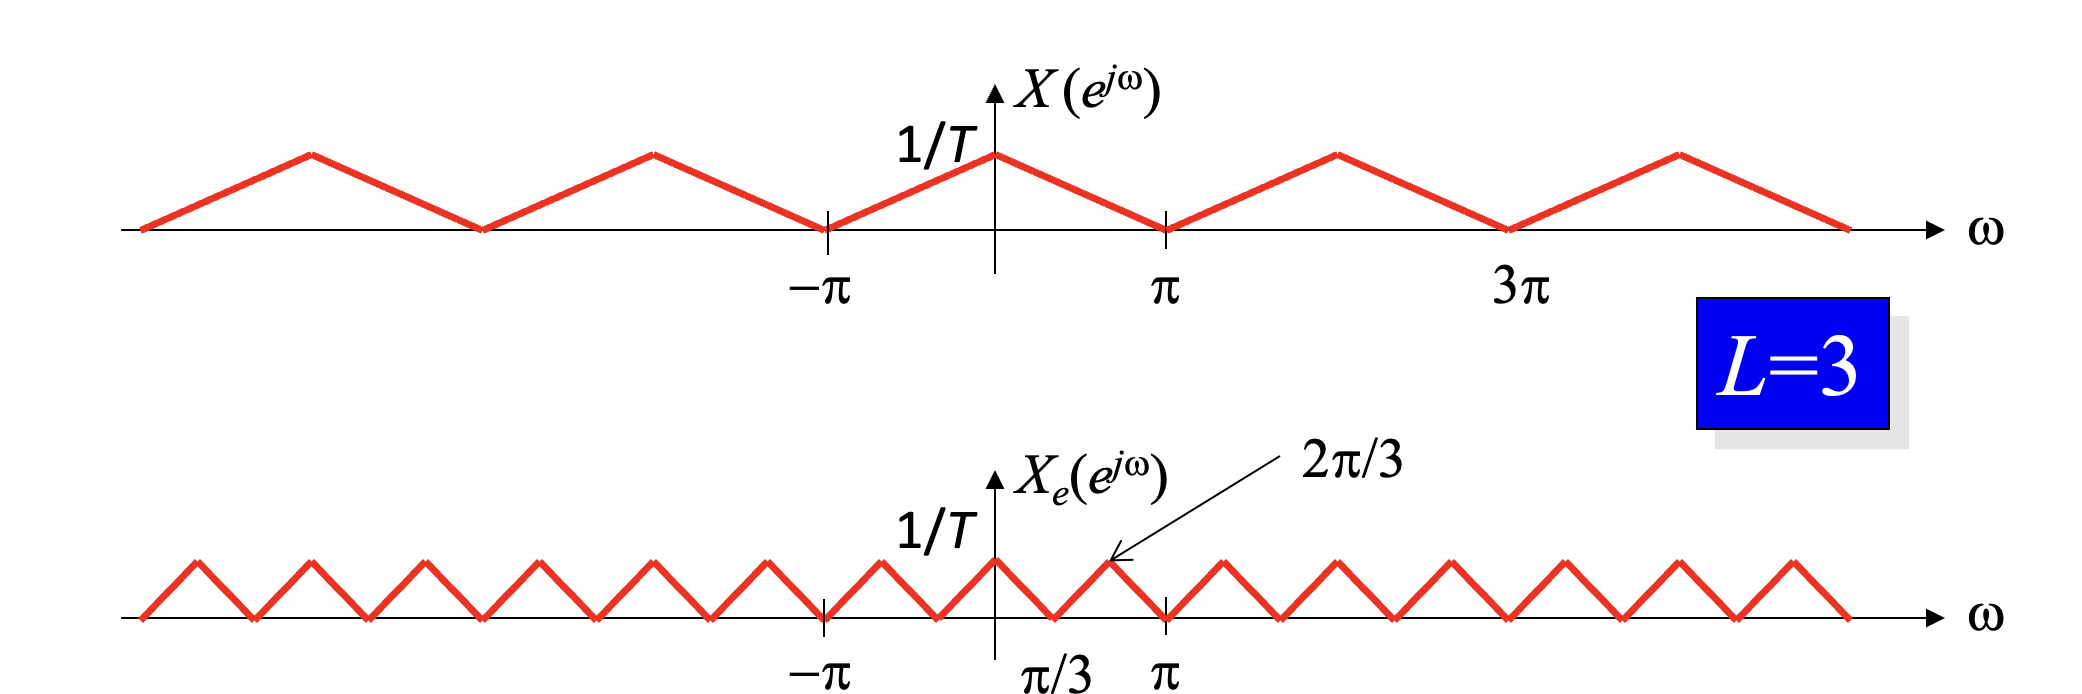

**Estágio 2 — Filtragem com ganho $L$**

Filtro passa-baixa com $\omega_c = \pi/L$ e **ganho $L$** elimina as imagens:

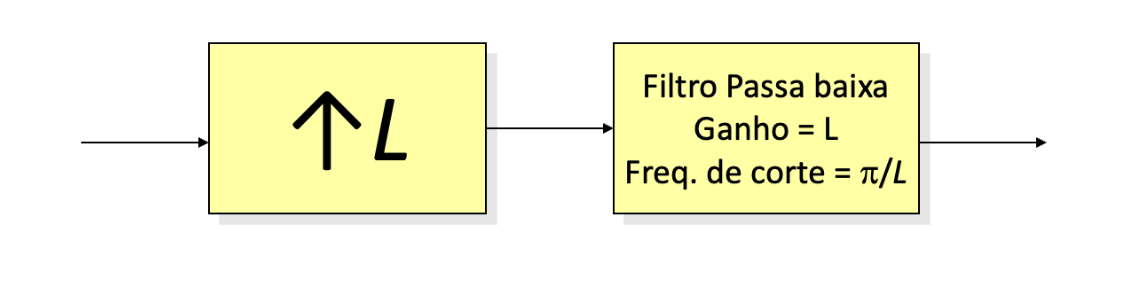



<div style="background-color: #EAFAF1; border-left: 4px solid #117A65; padding: 12px; border-radius: 4px; margin: 12px 0;">
<strong style="color: #117A65;">Por que ganho $L$?</strong><br>
Inserir $L-1$ zeros reduz a energia do sinal por fator $L$.
O filtro com ganho $L$ compensa exatamente essa perda, preservando a amplitude original.
Sem esse ganho, o sinal interpolado teria amplitude $1/L$.
</div>



---

## <span style="color: #1A5FA8;">4b. Interpolação Sinc — Reconstrução pelo Filtro Ideal</span>

<div style="background-color: #EAF2FB; border-left: 4px solid #1A5FA8; padding: 14px; border-radius: 4px; margin: 12px 0;">
<strong style="color: #1A5FA8;">Conexão com a teoria:</strong><br>
Na Seção 4 vimos que o interpolador ideal é um filtro passa-baixa com
frequência de corte $\omega_c = \pi/L$ e ganho $L$. No domínio do tempo,
esse filtro tem resposta ao impulso:

$$h(t) = \operatorname{sinc}\!\left(\frac{t}{T_s}\right) = \frac{\sin(\pi t / T_s)}{\pi t / T_s}$$

e a saída do interpolador é a <strong>soma de funções sinc</strong>, cada uma centrada
em um instante de amostragem e escalada pelo valor da amostra:

$$x_i(t) = \sum_{k=-\infty}^{+\infty} x(k)\cdot\operatorname{sinc}\!\left(\frac{t}{T_s} - k\right)$$

Este experimento visualiza cada etapa desse processo — do sinal original até a reconstrução sinc completa.
</div>

### O processo em 4 etapas

| Etapa | Operação | O que ver |
|---|---|---|
| 1 | Sinal original $x(n)$ | Amostras discretas — ponto de partida |
| 2 | Expansão $x_e(n)$ — inserção de $L-1$ zeros | Zeros entre amostras (upsampler ↑L) |
| 3 | Sincs individuais $s_k(t) = x(k)\cdot\operatorname{sinc}(t/T_s - k)$ | Cada amostra gera uma sinc escalada |
| 4 | Sinal interpolado $x_i(t)$ — soma das sincs | Reconstrução contínua passando pelas amostras |

> **Parâmetro principal:** altere `L` na célula de parâmetros e reexecute para
> ver como o fator de interpolação afeta a densidade da reconstrução.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.color':       '#dee2e6',
    'grid.linewidth':   0.6,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   12,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
})

# ── Parâmetros ───────────────────────────────────────────────────────────────
L = 4          # fator de interpolação (inteiro >= 2)

# Sinal original x(n): altere à vontade
x = np.array([0.2, 0.7, 1.0, 0.6, -0.3, -0.8, 0.4, 0.9])
n = np.arange(len(x))          # índices das amostras: 0, 1, 2, ...

print(f"Fator de interpolação : L = {L}")
print(f"Número de amostras    : N = {len(x)}")
print(f"Amostras x(n)         : {x}")

### Funções auxiliares

As três funções abaixo implementam o pipeline completo da interpolação sinc.

In [ ]:
def sinc_norm(t):
    """Função sinc normalizada: sinc(t) = sin(π·t) / (π·t), com sinc(0) = 1."""
    return np.sinc(t)   # numpy.sinc já usa a convenção normalizada


def expand_signal(x, L):
    """Insere L-1 zeros entre cada amostra de x (expansor ↑L)."""
    N = len(x)
    xe = np.zeros(N * L)
    xe[::L] = x
    ne = np.arange(len(xe))
    return xe, ne


def interpolate_sinc(x, n, L, oversample=200):
    """
    Reconstrói o sinal contínuo x_i(t) pela soma de sincs.

    Parâmetros
    ----------
    x          : amostras originais
    n          : índices das amostras originais
    L          : fator de interpolação
    oversample : pontos por intervalo entre amostras originais

    Retorna
    -------
    t_cont  : eixo de tempo contínuo (em unidades de T_s)
    xi      : sinal interpolado
    sincs   : lista de arrays com cada contribuição sinc individual
    """
    t_cont = np.linspace(n[0], n[-1], (len(n) - 1) * L * oversample + 1)
    xi     = np.zeros_like(t_cont)
    sincs  = []
    for k, xk in zip(n, x):
        s = xk * sinc_norm(t_cont - k)
        xi += s
        sincs.append(s)
    return t_cont, xi, sincs

### Etapa 1 — Sinal original $x(n)$

As amostras $x(n)$ são o ponto de partida. Cada amostra gerará uma função sinc
centrada em seu instante e escalada por seu valor.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 3.5))

# Linha de zero
ax.axhline(0, color='#495057', linewidth=0.8, zorder=1)

# Hastes (stem)
for k, xk in zip(n, x):
    color = '#1971c2' if xk >= 0 else '#c92a2a'
    ax.plot([k, k], [0, xk], color=color, linewidth=2.2, zorder=2)
    ax.plot(k, xk, 'o', markersize=9, color=color,
            markeredgecolor='white', markeredgewidth=1.2, zorder=3)

ax.set_xlim(n[0] - 0.8, n[-1] + 0.8)
ax.set_xticks(n)
ax.set_xlabel('n  (índice de amostra)')
ax.set_ylabel('x(n)')
ax.set_title('Sinal original  x(n)')

# Anotações de valor
for k, xk in zip(n, x):
    offset = 0.07 if xk >= 0 else -0.12
    ax.text(k, xk + offset, f'{xk:.1f}', ha='center', va='bottom',
            fontsize=9, color='#343a40')

plt.tight_layout()
plt.savefig('fig1_sinal_original.png', dpi=150, bbox_inches='tight')
plt.show()

### Etapa 2 — Sinal expandido $x_e(n)$ com zeros inseridos

O upsampler ↑L insere $L-1$ zeros entre cada amostra original.
As amostras originais (azul) ficam nas posições $n = 0, L, 2L, \ldots$
Os zeros (laranja) ocupam todas as posições intermediárias.

<div style="background-color: #FEF9E7; border-left: 4px solid #E67E22; padding: 11px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #E67E22;">Por que inserir zeros?</strong><br>
Os zeros não carregam informação — são espaços reservados para o filtro preencher.
No domínio da frequência, essa operação comprime o espectro por $L$ e cria $L-1$
imagens espectrais (vistas na Seção 5 — Simulador de Interpolação).
</div>


In [ ]:
xe, ne = expand_signal(x, L)

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.axhline(0, color='#495057', linewidth=0.8, zorder=1)

for k, xek in zip(ne, xe):
    is_orig = (k % L == 0)

    if is_orig:
        # Amostra original — haste + círculo azul
        color = '#1971c2' if xek >= 0 else '#c92a2a'
        ax.plot([k, k], [0, xek], color=color, linewidth=2.2, zorder=2)
        ax.plot(k, xek, 'o', markersize=9, color=color,
                markeredgecolor='white', markeredgewidth=1.2, zorder=4)
    else:
        # Zero inserido — haste pontilhada + marcador ×
        ax.plot([k, k], [0, 0.0], color='#868e96',
                linewidth=1.2, linestyle=':', zorder=2)
        ax.plot(k, 0, 'x', markersize=8, color='#e67700',
                markeredgewidth=2.0, zorder=3)

ax.set_xlim(ne[0] - 0.8, ne[-1] + 0.8)
ax.set_xticks(ne[::L])          # marcas apenas nas amostras originais
ax.set_xticklabels([f'{k}\n(orig n={k//L})' for k in ne[::L]], fontsize=8)
ax.set_xlabel('n  (índice do sinal expandido)')
ax.set_ylabel('$x_e(n)$')
ax.set_title(f'Sinal expandido  $x_e(n)$  —  L = {L}  (↑{L})')

# Legenda manual
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#1971c2',
           markersize=9, label='Amostra original'),
    Line2D([0], [0], marker='x', color='#e67700', markersize=9,
           markeredgewidth=2, linestyle='None', label='Zero inserido'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('fig2_sinal_expandido.png', dpi=150, bbox_inches='tight')
plt.show()

### Etapa 3 — Funções sinc individuais

Cada amostra $x(k)$ gera uma função sinc centrada em $t = k$ e escalada por $x(k)$:

$$s_k(t) = x(k)\cdot\operatorname{sinc}\!\left(\frac{t}{T_s} - k\right)$$

**Propriedade fundamental da sinc:**

$$s_k(m) = \begin{cases} x(k) & m = k \\\\ 0 & m \neq k,\; m \in \mathbb{Z} \end{cases}$$

Cada sinc vale exatamente $x(k)$ no seu instante e zero nos demais — garantindo
que a soma interpole exatamente pelas amostras originais.


In [ ]:
t_cont, xi, sincs = interpolate_sinc(x, n, L)

# Paleta de cores para as N sincs
cmap = plt.cm.get_cmap('tab10', len(x))
colors_sinc = [cmap(i) for i in range(len(x))]

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.axhline(0, color='#495057', linewidth=0.8, zorder=1)

for k, xk, s, c in zip(n, x, sincs, colors_sinc):
    ax.plot(t_cont, s, linewidth=1.6, color=c,
            label=f'$x({k})={xk:+.1f}\\cdot\\mathrm{{sinc}}(t-{k})$')
    # Marca o pico da sinc
    ax.plot(k, xk, 'o', markersize=7, color=c,
            markeredgecolor='white', markeredgewidth=1.0, zorder=5)

ax.set_xlim(t_cont[0] - 0.3, t_cont[-1] + 0.3)
ax.set_xlabel('t / $T_s$  (tempo normalizado)')
ax.set_ylabel('amplitude')
ax.set_title('Funções sinc individuais  $s_k(t) = x(k)\\cdot\\mathrm{sinc}(t-k)$')
ax.legend(fontsize=8.5, ncol=2, loc='upper right',
          framealpha=0.9, edgecolor='#dee2e6')

plt.tight_layout()
plt.savefig('fig3_sincs_individuais.png', dpi=150, bbox_inches='tight')
plt.show()

### Etapa 4 — Sinal interpolado $x_i(t)$

A soma de todas as sincs individuais produz o sinal reconstruído.
O resultado passa exatamente pelas amostras originais (círculos azuis) —
consequência direta da propriedade de ortogonalidade da sinc.


In [ ]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.axhline(0, color='#495057', linewidth=0.8, zorder=1)

# Sincs individuais (fundo, mais transparentes)
for s, c in zip(sincs, colors_sinc):
    ax.plot(t_cont, s, linewidth=1.0, color=c, alpha=0.35, zorder=2)

# Sinal interpolado (destaque)
ax.plot(t_cont, xi, linewidth=2.8, color='#5c2d91',
        label='$x_i(t)$ — sinal interpolado', zorder=4)

# Amostras originais
ax.stem(n, x, linefmt='#1971c2', markerfmt='o', basefmt=' ')
# Sobreposição com marcador melhorado
ax.plot(n, x, 'o', markersize=9, color='#1971c2',
        markeredgecolor='white', markeredgewidth=1.4,
        zorder=6, label='Amostras originais $x(n)$')

# Amostras interpoladas
n_interp = np.arange(len(x) * L) / L
xi_at_interp = np.array([np.interp(ni, t_cont, xi) for ni in n_interp])
mask_zeros = np.array([(k % L != 0) for k in range(len(n_interp))])
ax.plot(n_interp[mask_zeros], xi_at_interp[mask_zeros],
        'x', markersize=8, color='#e67700', markeredgewidth=2,
        zorder=5, label=f'Amostras interpoladas (L={L})')

ax.set_xlim(t_cont[0] - 0.3, t_cont[-1] + 0.3)
ax.set_xlabel('t / $T_s$  (tempo normalizado)')
ax.set_ylabel('amplitude')
ax.set_title(f'Sinal interpolado  $x_i(t)$  —  L = {L}')
ax.legend(fontsize=10, loc='upper right',
          framealpha=0.9, edgecolor='#dee2e6')

plt.tight_layout()
plt.savefig('fig4_sinal_interpolado.png', dpi=150, bbox_inches='tight')
plt.show()

### Painel completo — todas as etapas juntas

Visualização integrada das 4 etapas em um único painel.


In [2]:
fig = plt.figure(figsize=(14, 14))
gs  = gridspec.GridSpec(4, 1, figure=fig, hspace=0.52)

# ── Painel 1: sinal original ──────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.axhline(0, color='#495057', linewidth=0.8)
for k, xk in zip(n, x):
    c = '#1971c2' if xk >= 0 else '#c92a2a'
    ax1.plot([k, k], [0, xk], color=c, linewidth=2.2)
    ax1.plot(k, xk, 'o', markersize=9, color=c,
             markeredgecolor='white', markeredgewidth=1.2, zorder=3)
    ax1.text(k, xk + (0.07 if xk >= 0 else -0.13), f'{xk:.1f}',
             ha='center', fontsize=8.5, color='#343a40')
ax1.set_xlim(n[0] - 0.8, n[-1] + 0.8)
ax1.set_xticks(n)
ax1.set_title('① Sinal original  $x(n)$', loc='left')
ax1.set_ylabel('$x(n)$')

# ── Painel 2: sinal expandido ─────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.axhline(0, color='#495057', linewidth=0.8)
for k, xek in zip(ne, xe):
    is_orig = (k % L == 0)
    if is_orig:
        c = '#1971c2' if xek >= 0 else '#c92a2a'
        ax2.plot([k, k], [0, xek], color=c, linewidth=2.2)
        ax2.plot(k, xek, 'o', markersize=9, color=c,
                 markeredgecolor='white', markeredgewidth=1.2, zorder=4)
    else:
        ax2.plot(k, 0, 'x', markersize=8, color='#e67700',
                 markeredgewidth=2.0, zorder=3)
ax2.set_xlim(ne[0] - 0.8, ne[-1] + 0.8)
ax2.set_xticks(ne[::L])
ax2.set_xticklabels([f'{k}' for k in ne[::L]])
ax2.set_title(f'② Sinal expandido  $x_e(n)$  — L = {L}  (× = zeros inseridos)', loc='left')
ax2.set_ylabel('$x_e(n)$')
legend_exp = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#1971c2', markersize=8, label='Original'),
    Line2D([0],[0], marker='x', color='#e67700', markersize=8, markeredgewidth=2,
           linestyle='None', label='Zero inserido'),
]
ax2.legend(handles=legend_exp, fontsize=9, loc='upper right')

# ── Painel 3: sincs individuais ───────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
ax3.axhline(0, color='#495057', linewidth=0.8)
for k, xk, s, c in zip(n, x, sincs, colors_sinc):
    ax3.plot(t_cont, s, linewidth=1.6, color=c,
             label=f'n={k}, x={xk:+.1f}')
    ax3.plot(k, xk, 'o', markersize=6, color=c,
             markeredgecolor='white', markeredgewidth=1.0, zorder=5)
ax3.set_xlim(t_cont[0] - 0.3, t_cont[-1] + 0.3)
ax3.set_title('③ Funções sinc individuais  $s_k(t) = x(k)\\cdot\\mathrm{sinc}(t-k)$', loc='left')
ax3.set_ylabel('amplitude')
ax3.legend(fontsize=8, ncol=4, loc='upper right', framealpha=0.9)

# ── Painel 4: sinal interpolado ───────────────────────────────────────────────
ax4 = fig.add_subplot(gs[3])
ax4.axhline(0, color='#495057', linewidth=0.8)
for s, c in zip(sincs, colors_sinc):
    ax4.plot(t_cont, s, linewidth=0.9, color=c, alpha=0.3)
ax4.plot(t_cont, xi, linewidth=2.8, color='#5c2d91',
         label='$x_i(t)$ — interpolado', zorder=4)
ax4.plot(n, x, 'o', markersize=9, color='#1971c2',
         markeredgecolor='white', markeredgewidth=1.4,
         zorder=6, label='$x(n)$ — originais')
ax4.plot(n_interp[mask_zeros], xi_at_interp[mask_zeros],
         'x', markersize=8, color='#e67700', markeredgewidth=2.0,
         zorder=5, label=f'Amostras inseridas (L={L})')
ax4.set_xlim(t_cont[0] - 0.3, t_cont[-1] + 0.3)
ax4.set_xlabel('t / $T_s$')
ax4.set_title(f'④ Sinal interpolado  $x_i(t)$  — L = {L}', loc='left')
ax4.set_ylabel('$x_i(t)$')
ax4.legend(fontsize=9.5, loc='upper right', framealpha=0.9)

fig.suptitle(f'Interpolação por fator inteiro  L = {L}  —  Reconstrução via Sinc',
             fontsize=14, fontweight='bold', y=1.01)

plt.savefig('fig_painel_completo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Painel salvo em fig_painel_completo.png')

NameError: name 'plt' is not defined

### Experimento — efeito do fator $L$

Compare o sinal interpolado para $L = 2, 4, 8$.
Quanto maior $L$, mais densa a grade temporal e mais suave a curva reconstruída.


In [ ]:
fatores = [2, 4, 8]

fig, axes = plt.subplots(len(fatores), 1, figsize=(13, 4.0 * len(fatores)),
                         sharex=False)

for ax, Li in zip(axes, fatores):
    t_i, xi_i, _ = interpolate_sinc(x, n, Li)

    ax.axhline(0, color='#495057', linewidth=0.8)
    ax.plot(t_i, xi_i, linewidth=2.2, color='#5c2d91',
            label=f'L = {Li}')
    ax.plot(n, x, 'o', markersize=9, color='#1971c2',
            markeredgecolor='white', markeredgewidth=1.4,
            zorder=5, label='$x(n)$')

    # Amostras interpoladas
    n_int = np.arange(len(x) * Li) / Li
    xi_int = np.array([np.interp(ni, t_i, xi_i) for ni in n_int])
    mask = np.array([(k % Li != 0) for k in range(len(n_int))])
    ax.plot(n_int[mask], xi_int[mask], 'x',
            markersize=7, color='#e67700', markeredgewidth=1.8,
            zorder=4, label='Amostras inseridas')

    ax.set_ylabel('amplitude')
    ax.set_title(f'L = {Li}  —  Taxa de amostragem aumentada em {Li}×', loc='left')
    ax.legend(fontsize=9.5, loc='upper right')

axes[-1].set_xlabel('t / $T_s$')
fig.suptitle('Efeito do fator de interpolação L sobre o sinal reconstruído',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_variacao_L.png', dpi=150, bbox_inches='tight')
plt.show()

### 💡 O que observar

<div style="background-color: #EAFAF1; border-left: 4px solid #117A65; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #117A65;">Gráfico 3 — Sincs individuais</strong><br>
Cada sinc tem amplitude igual à amostra que a gerou. Observe que no instante
$t = k$ de uma sinc, todas as outras sincs valem zero — é essa propriedade
que garante a interpolação exata pelas amostras.
</div>

<div style="background-color: #EAF2FB; border-left: 4px solid #1A5FA8; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #1A5FA8;">Gráfico 4 — Sinal reconstruído</strong><br>
A curva roxa passa exatamente pelos círculos azuis (amostras originais).
Entre os instantes de amostragem, a sinc "interpola" os valores — isso é o
filtro passa-baixa ideal agindo no domínio do tempo.
</div>

<div style="background-color: #FEF9E7; border-left: 4px solid #E67E22; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #E67E22;">Variação de L</strong><br>
Aumentar $L$ não muda o formato da curva reconstruída — apenas aumenta a
densidade de pontos calculados. A reconstrução sinc é a mesma para qualquer $L$,
pois depende apenas das amostras originais $x(n)$, não do fator de interpolação.
</div>

<div style="background-color: #FDEDEC; border-left: 4px solid #A32D2D; padding: 12px; border-radius: 4px; margin: 10px 0;">
<strong style="color: #A32D2D;">Limitação prática</strong><br>
A sinc tem suporte infinito — cada amostra contribui para todos os instantes,
incluindo os mais distantes. Na prática, trunca-se a sinc com uma janela (Hann,
Kaiser, Blackman), resultando em um filtro FIR de comprimento finito que aproxima
o comportamento ideal com erro controlável.
</div>


### Resumo — Interpolação Sinc

| Etapa | Operação | Notação |
|---|---|---|
| 1 | Sinal original | $x(n)$ |
| 2 | Inserção de $L-1$ zeros (expansor ↑L) | $x_e(n)$ |
| 3 | Filtro passa-baixa ideal (ganho $L$, corte $\pi/L$) | equivalente à soma de sincs |
| 4 | Sinal interpolado | $x_i(t) = \sum_k x(k)\,\operatorname{sinc}(t/T_s - k)$ |

> **Nota:** o filtro passa-baixa ideal no domínio da frequência corresponde
> exatamente à interpolação sinc no domínio do tempo. Na prática, filtros FIR
> de comprimento finito aproximam esse comportamento com erro controlável.


---

## <span style="color: #1A5FA8;">6. Experimento com Voz — Decimação de Sinal Real</span>

<div style="background-color: #EAF2FB; border-left: 4px solid #1A5FA8; padding: 12px; border-radius: 4px; margin: 12px 0;">
<strong style="color: #1A5FA8;">Frase sugerida:</strong><br>
<em style="font-size: 1.05em;">"As folhas frescas caem suavemente sobre o chão seco e frio."</em><br><br>
Cobre desde vogais graves (/a/, /o/ — 200–3.000 Hz) até fricativas agudas (/f/, /s/, /ch/ — 2–12 kHz).
</div>

| Fator $M$ | $F_s^y$ | $F_{Nyquist}$ | O que some |
|:---:|:---:|:---:|---|
| 1 | 44.100 Hz | 22.050 Hz | Referência |
| 4 | 11.025 Hz | 5.512 Hz | /f/ e /s/ fracos |
| 8 | 5.512 Hz | 2.756 Hz | /f/, /s/, /ch/ comprometidos |
| 50 | 882 Hz | 441 Hz | Apenas graves — irreconhecível |

<div style="background-color: #FDEDEC; border-left: 4px solid #A32D2D; padding: 11px; border-radius: 4px; margin: 12px 0;">
<strong style="color: #A32D2D;"> Ao executar:</strong> clique no botão e fale claramente por 5 segundos.
</div>


### Etapa 1 — Configuração do experimento

In [15]:
FS_ORIG = 44100   # Hz — taxa de gravação
DURACAO = 5       # s
FATORES = [1, 4, 8, 50]

print('Configuração do experimento de voz:')
print(f'  Taxa de gravação : {FS_ORIG} Hz')
print(f'  Duração          : {DURACAO} s')
print()
print(f'{"M":>4} | {"Fs_y (Hz)":>10} | {"Nyquist (Hz)":>13} | Qualidade esperada')
print('-' * 65)
descricoes = ['Referência (CD)', 'Boa — /f/ e /s/ fracos', 
              'Degradada — fricativas comprometidas', 'Irreconhecível']
for M, desc in zip(FATORES, descricoes):
    fs_y = FS_ORIG // M
    print(f'{M:>4} | {fs_y:>10,} | {fs_y//2:>13,} | {desc}')


Configuração do experimento de voz:
  Taxa de gravação : 44100 Hz
  Duração          : 5 s

   M |  Fs_y (Hz) |  Nyquist (Hz) | Qualidade esperada
-----------------------------------------------------------------
   1 |     44,100 |        22,050 | Referência (CD)
   4 |     11,025 |         5,512 | Boa — /f/ e /s/ fracos
   8 |      5,512 |         2,756 | Degradada — fricativas comprometidas
  50 |        882 |           441 | Irreconhecível


### Etapa 2 — Função de processamento e análise

In [16]:
def processar_e_plotar(audio, fs_orig):
    '''Decima o áudio por cada fator M, plota espectrograma e reproduz.'''
    for M in FATORES:
        fs_y = int(fs_orig / M)
        dec  = resample_poly(audio, 1, M) if M > 1 else audio.copy()

        fig = plt.figure(figsize=(14, 4), facecolor='white')
        plt.subplots_adjust(top=0.82, bottom=0.12,
                            left=0.07, right=0.97, wspace=0.35)
        gs = gridspec.GridSpec(1, 2, figure=fig)

        # Forma de onda
        ax1 = fig.add_subplot(gs[0, 0])
        ax1.plot(dec, lw=0.3, color=C_ORIG)
        ax1.set_title(f'Forma de onda — M={M}  |  Fs={fs_y} Hz')
        ax1.set_xlabel('Amostras'); ax1.set_ylabel('Amplitude')
        ax1.grid(True, alpha=0.3, ls=':')

        # Espectrograma
        ax2 = fig.add_subplot(gs[0, 1])
        nperseg = min(1024, max(64, len(dec) // 8))
        f_sg, t_sg, Sxx = spectrogram(dec, fs_y, nperseg=nperseg)
        pcm = ax2.pcolormesh(t_sg, f_sg / 1000,
                             10 * np.log10(Sxx + 1e-10),
                             shading='gouraud', cmap='viridis')
        plt.colorbar(pcm, ax=ax2, label='dB')
        ax2.set_title(f'Espectrograma — Nyquist = {fs_y//2} Hz')
        ax2.set_xlabel('Tempo (s)'); ax2.set_ylabel('Frequência (kHz)')

        cor = C_DCOM if M == 1 else C_ORIG
        fig.suptitle(f'Fator M = {M}  |  Fs = {fs_orig} → {fs_y} Hz  |  '
                     f'Nyquist = {fs_y//2} Hz',
                     fontsize=11, fontweight='bold', color=cor, y=0.97)
        plt.show()

        display(ipd.HTML(f'<b>▶ M={M} | Fs={fs_y} Hz | {len(dec):,} amostras:</b>'))
        display(ipd.Audio(dec, rate=fs_y))
        print('-' * 65)

print('✅  Função processar_e_plotar() definida.')


✅  Função processar_e_plotar() definida.


### Etapa 3 — Gravar e executar o experimento

In [ ]:
def ao_clicar(b):
    with saida:
        saida.clear_output()
        print(f'🔴 GRAVANDO {DURACAO} s — fale a frase agora!')
        grav = sd.rec(int(DURACAO * FS_ORIG),
                      samplerate=FS_ORIG, channels=1, dtype='float32')
        sd.wait()
        print('✅ Concluído! Processando M = 1, 4, 8, 50...')
        print('=' * 65)
        processar_e_plotar(grav.flatten(), FS_ORIG)

botao = widgets.Button(
    description='🎙️  Gravar e Analisar',
    button_style='danger',
    layout=widgets.Layout(width='220px', height='42px')
)
saida = widgets.Output()
botao.on_click(ao_clicar)
print('Clique para iniciar a gravação de 5 segundos:')
display(botao, saida)


Clique para iniciar a gravação de 5 segundos:


Button(button_style='danger', description='🎙️  Gravar e Analisar', layout=Layout(height='42px', width='220px')…

Output()

### 💡 O que registrar após ouvir

| Fator $M$ | /f/ e /s/ audíveis? | Vogais inteligíveis? | Qualidade (1–5) |
|:---:|:---:|:---:|:---:|
| 1 | | | |
| 4 | | | |
| 8 | | | |
| 50 | | | |

**Pergunta:** qual é o menor $M$ em que a frase deixa de ser inteligível?
Compare com $M_{crit} = \lfloor F_s/(2 \times 4000) \rfloor$ (voz até ≈ 4 kHz).


---

## <span style="color: #1A5FA8;">7. Conversão Racional — Taxa $L/M$</span>

Para converter entre taxas não inteiras, combina-se interpolação e decimação:

$$\boxed{F_s^y = F_s^x \cdot \frac{L}{M}}$$

### Pipeline completo

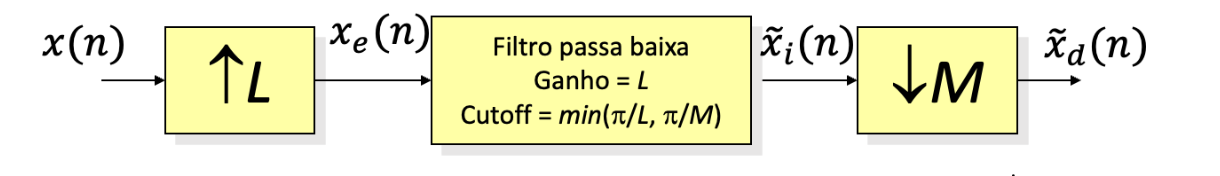

<div style="background-color: #FEF9E7; border-left: 4px solid #E67E22; padding: 12px; border-radius: 4px; margin: 12px 0;">
<strong style="color: #E67E22;">Filtro único equivalente:</strong> os dois filtros separados (um de
interpolação e um de decimação) se fundem em um único mais eficiente:

$$\text{Cutoff} = \min\!\left(\frac{\pi}{L},\; \frac{\pi}{M}\right) = \frac{\pi}{\max(L, M)}, \qquad \text{Ganho} = L$$

**Por que interpolar antes de decimar?** Se decimarmos primeiro, a taxa cai e pode
ocorrer aliasing irreversível. Interpolando primeiro, mantemos resolução suficiente.
</div>

### Por que a ordem importa — exemplo

Com $F_s = 40$ Hz, $L = 3$, $M = 4$ (conversão racional $3/4$, $F_s^y = 30$ Hz):

| Ordem errada | Ordem correta |
|---|---|
| ↓4 → $F_s = 10$ Hz → ↑3 | ↑3 → $F_s = 120$ Hz → ↓4 |
| Nyquist = 5 Hz antes de interpolar | Nyquist = 60 Hz durante todo o processo |
| Componentes de $F_0 = 5$ a 20 Hz: **aliasing** | Sem aliasing até o downsampler final |

### Exemplos práticos

| Conversão | $F_s^x$ | $F_s^y$ | $L$ | $M$ | Cutoff |
|---|---|---|---|---|---|
| CD → DAT | 44.100 Hz | 48.000 Hz | 160 | 147 | $\pi/160$ |
| Áudio → Telefone | 44.100 Hz | 8.000 Hz | 80 | 441 | $\pi/441$ |
| Telefone → Wideband | 8.000 Hz | 16.000 Hz | 2 | 1 | $\pi/2$ |



---

## <span style="color: #1A5FA8;">9. Questões para Reflexão</span>

### Sobre Decimação

1. Na Seção 1, para `decim=4` e $F_s = 8.192$ Hz: qual a nova taxa e o $F_{Nyquist}$?
   Quais harmônicos do sinal (440, 880, 1320, 1760, 2200, 2640, 3520 Hz) sobrevivem?

2. Na Seção 2b (experimento com imagem), compare as linhas 1 e 2 para M=4.
   O que o filtro anti-aliasing removeu da imagem? Há perda de informação?
   Essa perda é aceitável? Justifique.

3. Na Seção 2 (`Decimacao.grc`), altere `freq_cos` para 13.000 Hz e reexecute.
   Calcule $F_{alias}$ esperado para M=4:
   $$F_{alias} = |F_0 - \text{round}(F_0/F_s^y) \cdot F_s^y|$$

4. No Simulador (Seção 3), configure M=5:
   calcule $F_{alias}$ e confirme no gráfico 5.

5. No Experimento de voz (Seção 6), qual foi o menor M em que a frase deixou
   de ser inteligível? Justifique com $F_{Nyquist}^y$ e os fonemas afetados.

### Sobre Interpolação

6. Na Seção 2b (imagem), compare as linhas 3 e 4 para L=4.
   Por que a linha 4 (com filtro) não tem blocos pretos enquanto a linha 3 tem?
   Qual operação matemática o filtro realiza sobre os zeros?

7. Na Seção 4 (`Resampling.grc`), quantas imagens espectrais aparecem antes
   do filtro? Qual a fórmula que determina esse número?

8. No Simulador (Seção 5), configure L=4:
   - Qual é $\omega_c$ do filtro em rad/amostra?
   - Em Hz ($F_s = 40$ Hz), equivale a quantos Hz?
   - A amplitude do gráfico 4 foi preservada? Por quê?

---

## <span style="color: #1A5FA8;">Referências</span>

- **Oppenheim & Schafer** — *Processamento em Tempo Discreto de Sinais*, 3ª ed. Pearson, 2013. *(Cap. 4.6)*
- **Proakis & Manolakis** — *Digital Signal Processing*, 4ª ed. Pearson, 2007. *(Cap. 11)*
- **Crochiere & Rabiner** — *Multirate Digital Signal Processing*, Prentice-Hall, 1983.
- **Purdue ECE 438 Lab 4b** — Roteiro de laboratório com sinal de voz.

---

<div style="text-align: center; color: #888; font-size: 0.85em; margin-top: 20px;">
Laboratório de PDS — UFCG / DEE &nbsp;|&nbsp; Profa. Luciana Ribeiro Veloso
</div>
